# CineSense-AI: Exploratory Data Analysis

## Objective

This notebook explores movie, rating, genre, and user behavior patterns in the MovieLens dataset.

The analysis aims to identify insights that can guide the development of CineSense-AI features such as personalized recommendations, context-aware suggestions, hidden-gem discovery, and diversity-aware recommendations.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving movie_genres.csv to movie_genres.csv
Saving movies_final.csv to movies_final.csv
Saving ratings_clean.csv to ratings_clean.csv
Saving tags_clean.csv to tags_clean.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv("movies_final.csv")
ratings = pd.read_csv("ratings_clean.csv")
tags = pd.read_csv("tags_clean.csv")
movie_genres = pd.read_csv("movie_genres.csv")

# Convert datetime column
ratings["datetime"] = pd.to_datetime(ratings["datetime"])
tags["datetime"] = pd.to_datetime(tags["datetime"])

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Movie Genres:", movie_genres.shape)

Movies: (9742, 9)
Ratings: (100836, 5)
Tags: (3683, 6)
Movie Genres: (22084, 2)


## 1. Distribution of User Ratings

This analysis examines how users rate movies and identifies the most commonly assigned rating scores.

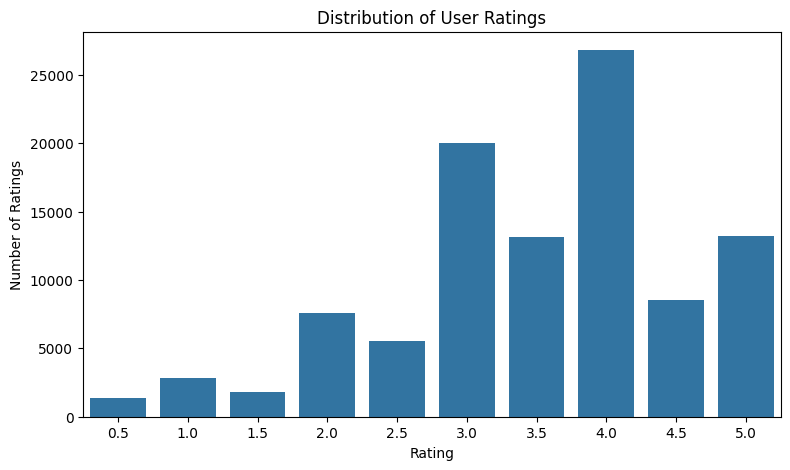

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

## 2. Movie Release Trends

This analysis examines how the number of movies in the dataset changes across release years.

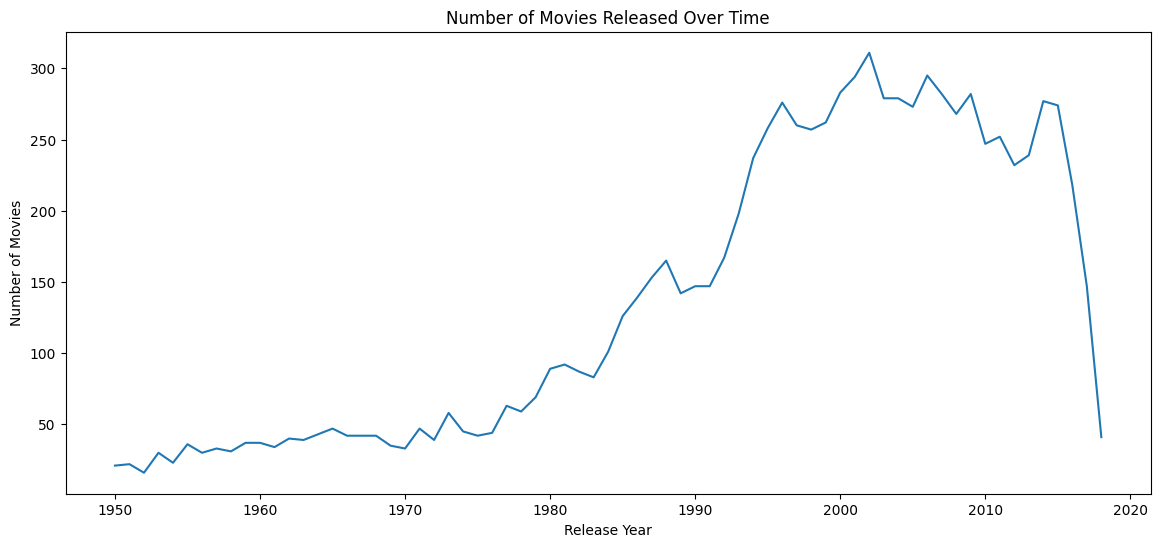

In [ ]:
movies_per_year = (
    movies.dropna(subset=["year"])
    .groupby("year")
    .size()
    .reset_index(name="movie_count")
)

# Focus on modern cinema for clearer visualization
movies_per_year = movies_per_year[
    movies_per_year["year"] >= 1950
]

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=movies_per_year,
    x="year",
    y="movie_count"
)

plt.title("Number of Movies Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

## 3. Most Common Movie Genres

This analysis identifies the genres with the largest number of movies in the dataset.

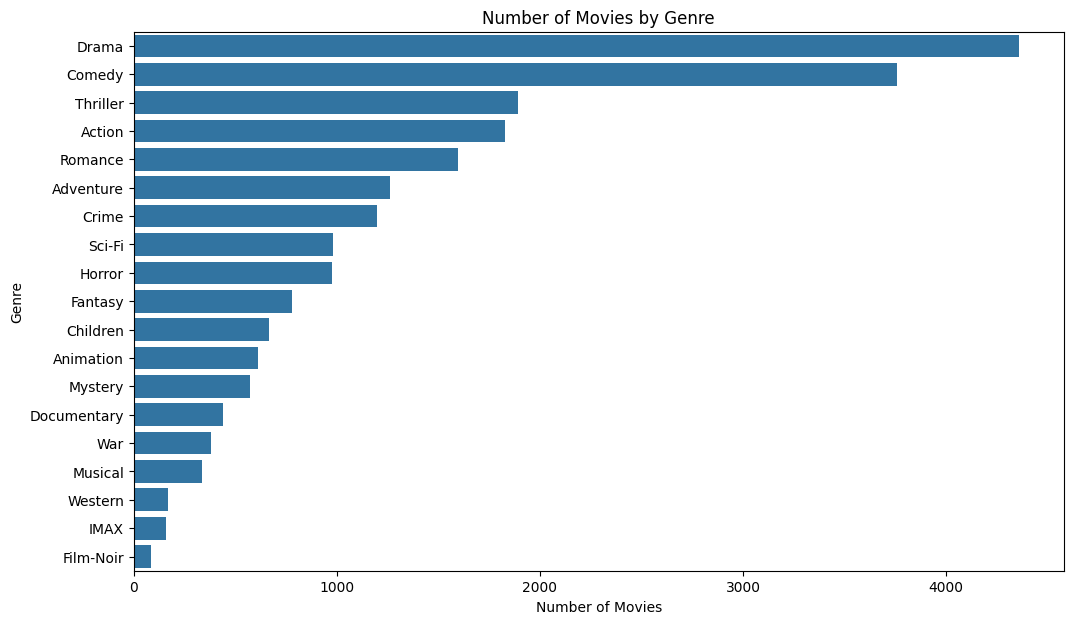

In [ ]:
genre_counts = (
    movie_genres[
        movie_genres["genre"] != "(no genres listed)"
    ]["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = [
    "genre",
    "movie_count"
]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_counts,
    x="movie_count",
    y="genre"
)

plt.title("Number of Movies by Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

## 4. Average Rating by Genre

This analysis compares average user ratings across movie genres to identify genres that tend to receive higher audience ratings.

Only genres with sufficient rating activity are considered when interpreting the results.

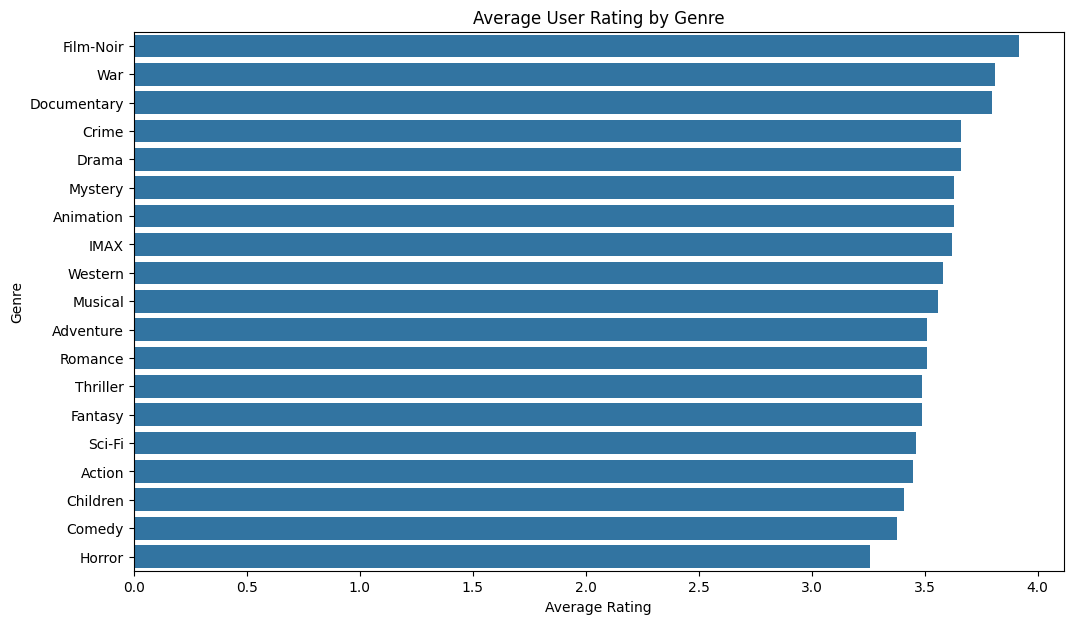

,genre,average_rating,total_ratings
9,Film-Noir,3.92,870
17,War,3.81,4859
6,Documentary,3.80,1219
5,Crime,3.66,16681
7,Drama,3.66,41928
13,Mystery,3.63,7674
2,Animation,3.63,6988
11,IMAX,3.62,4145
18,Western,3.58,1930
12,Musical,3.56,4138


In [ ]:
genre_ratings = (
    movie_genres
    .merge(
        ratings[["movieId", "rating"]],
        on="movieId",
        how="inner"
    )
)

genre_rating_stats = (
    genre_ratings[
        genre_ratings["genre"] != "(no genres listed)"
    ]
    .groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        total_ratings=("rating", "count")
    )
    .reset_index()
    .sort_values(
        "average_rating",
        ascending=False
    )
)

genre_rating_stats["average_rating"] = (
    genre_rating_stats["average_rating"].round(2)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_rating_stats,
    x="average_rating",
    y="genre"
)

plt.title("Average User Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

display(genre_rating_stats)

## 5. Movie Popularity vs Rating

This analysis examines the relationship between movie popularity, represented by the number of user ratings, and movie quality, represented by the average rating.

Movies with very few ratings are excluded to reduce noise.

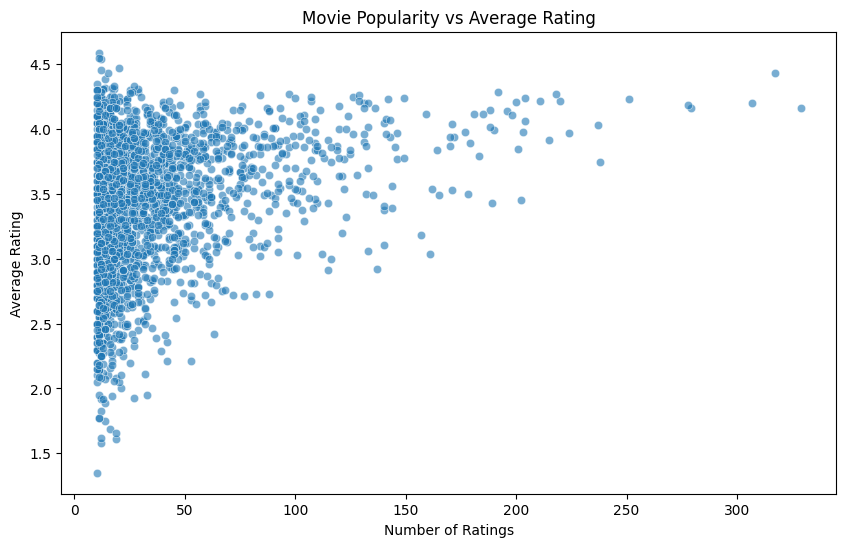

Correlation between popularity and average rating: 0.278


In [ ]:
popular_quality = movies[
    movies["rating_count"] >= 10
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=popular_quality,
    x="rating_count",
    y="average_rating",
    alpha=0.6
)

plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

correlation = popular_quality[
    ["rating_count", "average_rating"]
].corr().iloc[0, 1]

print(
    "Correlation between popularity and average rating:",
    round(correlation, 3)
)

## 6. User Rating Activity

This analysis examines how actively users interact with movies by measuring the number of ratings submitted by each user.

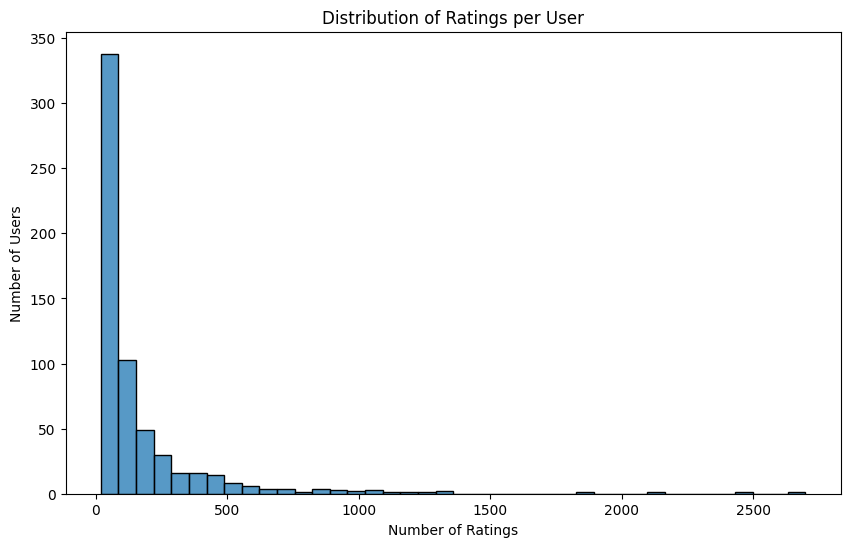

,rating_count
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


In [ ]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .reset_index(name="rating_count")
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_activity,
    x="rating_count",
    bins=40
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

display(
    user_activity["rating_count"].describe()
)

## 7. User-Movie Interaction Matrix Sparsity

Recommendation datasets are typically sparse because each user interacts with only a small fraction of all available movies.

This analysis calculates the percentage of possible user-movie interactions that actually contain a rating.

In [ ]:
unique_users = ratings["userId"].nunique()
unique_movies = ratings["movieId"].nunique()
actual_ratings = len(ratings)

possible_interactions = (
    unique_users * unique_movies
)

sparsity = (
    1 - (actual_ratings / possible_interactions)
) * 100

density = (
    actual_ratings / possible_interactions
) * 100

print("Unique Users:", unique_users)
print("Unique Rated Movies:", unique_movies)
print("Actual Ratings:", actual_ratings)
print("Possible User-Movie Interactions:", possible_interactions)

print(
    "\nMatrix Density:",
    round(density, 2),
    "%"
)

print(
    "Matrix Sparsity:",
    round(sparsity, 2),
    "%"
)

Unique Users: 610
Unique Rated Movies: 9724
Actual Ratings: 100836
Possible User-Movie Interactions: 5931640

Matrix Density: 1.7 %
Matrix Sparsity: 98.3 %


## 8. User Genre Diversity

This analysis measures how many unique genres each user has interacted with based on the movies they rated.

Understanding genre diversity can help determine whether recommendations should focus narrowly on preferred genres or introduce diverse suggestions.

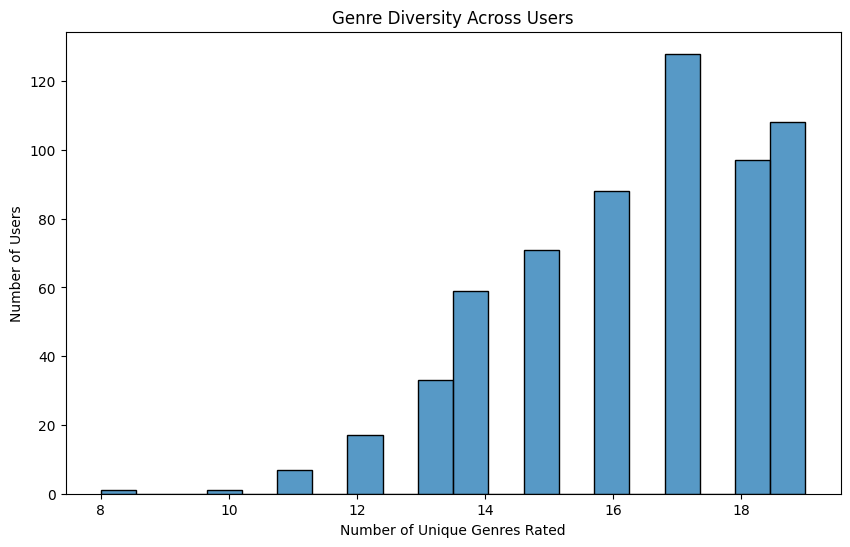

,unique_genres
count,610.000000
mean,16.395082
std,2.043768
min,8.000000
25%,15.000000
50%,17.000000
75%,18.000000
max,19.000000


In [ ]:
user_genres = (
    ratings[["userId", "movieId"]]
    .merge(
        movie_genres,
        on="movieId",
        how="inner"
    )
)

user_genre_diversity = (
    user_genres[
        user_genres["genre"] != "(no genres listed)"
    ]
    .groupby("userId")["genre"]
    .nunique()
    .reset_index(name="unique_genres")
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_genre_diversity,
    x="unique_genres",
    bins=20
)

plt.title("Genre Diversity Across Users")
plt.xlabel("Number of Unique Genres Rated")
plt.ylabel("Number of Users")

plt.show()

display(
    user_genre_diversity["unique_genres"].describe()
)

## 9. Hidden Gem Analysis

Potential hidden gems are movies that combine strong audience ratings with relatively lower popularity.

For this initial analysis, movies with an average rating of at least 4.0 and between 20 and 100 ratings are considered potential hidden gems.

In [ ]:
hidden_gems = (
    movies[
        (movies["average_rating"] >= 4.0)
        &
        (movies["rating_count"].between(20, 100))
    ]
    .sort_values(
        ["average_rating", "rating_count"],
        ascending=[False, False]
    )
)

display(
    hidden_gems[
        [
            "clean_title",
            "year",
            "genres",
            "rating_count",
            "average_rating"
        ]
    ].head(20)
)

,clean_title,year,genres,rating_count,average_rating
841,"Streetcar Named Desire, A",1951.0,Drama,20,4.47
704,Sunset Blvd. (a.k.a. Sunset Boulevard),1950.0,Drama|Film-Noir|Romance,27,4.33
680,"Philadelphia Story, The",1940.0,Comedy|Drama|Romance,29,4.31
906,Lawrence of Arabia,1962.0,Adventure|Drama|War,45,4.30
413,In the Name of the Father,1993.0,Drama,25,4.30
210,Hoop Dreams,1994.0,Documentary,29,4.29
935,Harold and Maude,1971.0,Comedy|Drama|Romance,26,4.29
9463,Logan,2017.0,Action|Sci-Fi,25,4.28
602,Dr. Strangelove or: How I Learned to Stop Worr...,1964.0,Comedy|War,97,4.27
975,Cool Hand Luke,1967.0,Drama,57,4.27


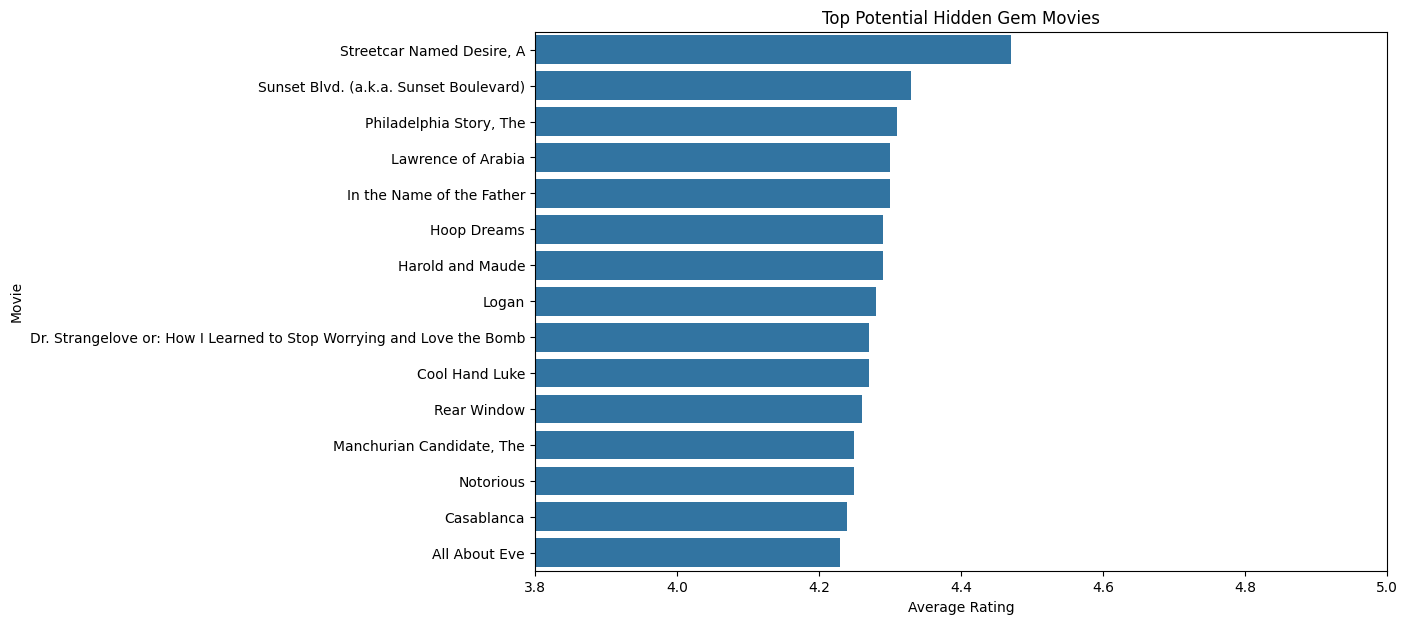

In [ ]:
top_hidden_gems = hidden_gems.head(15)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_hidden_gems,
    x="average_rating",
    y="clean_title"
)

plt.title("Top Potential Hidden Gem Movies")
plt.xlabel("Average Rating")
plt.ylabel("Movie")

plt.xlim(3.8, 5)

plt.show()

## 10. Rating Activity Over Time

This analysis examines how user rating activity changes over time based on the year in which ratings were submitted.

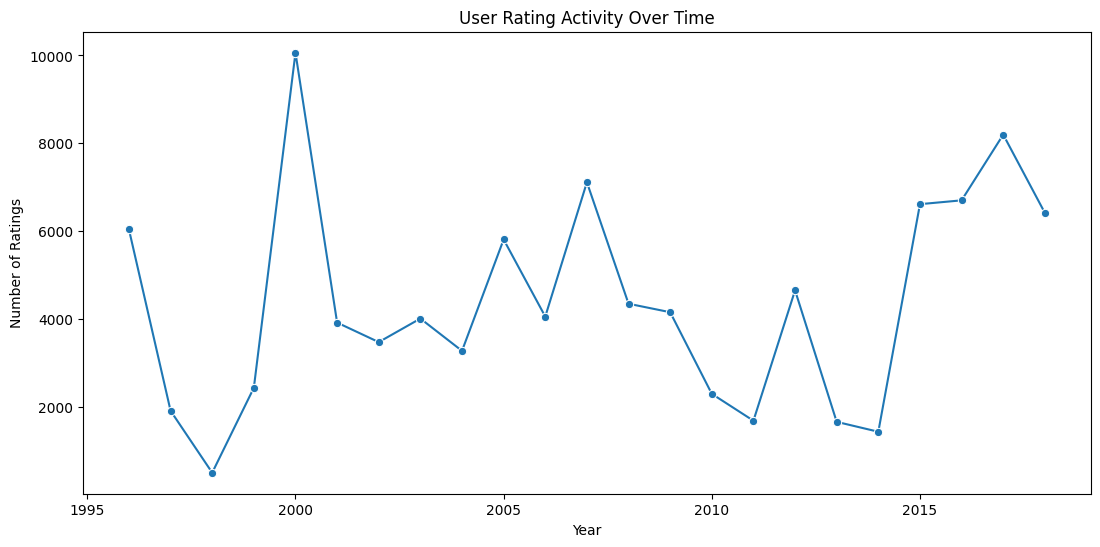

In [ ]:
ratings["rating_year"] = ratings["datetime"].dt.year

ratings_over_time = (
    ratings.groupby("rating_year")
    .size()
    .reset_index(name="rating_count")
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=ratings_over_time,
    x="rating_year",
    y="rating_count",
    marker="o"
)

plt.title("User Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

## Key EDA Findings

- User ratings are centered around **3.5**, with higher ratings such as 4.0 being commonly assigned.
- Movie popularity and average rating should be treated as separate factors when ranking recommendations.
- The user-movie interaction matrix is highly sparse, indicating that collaborative filtering alone may not be sufficient.
- Users show varying levels of rating activity and genre diversity, supporting the need for personalized recommendations.
- Genre preferences provide valuable signals for understanding individual movie tastes.
- Highly rated but moderately popular movies can be identified as potential **hidden gems**.
- These findings support the development of a **hybrid recommendation approach** combining movie content, user behavior, contextual preferences, and popularity signals.